# Scale $S(s_x, s_y, x_0, y_0)$
Notebook to help with deriving closed-form geometric transforms and their gradients.

In [1]:
import sympy
from sympy import Matrix, Symbol

x0 = Symbol("x_0")
y0 = Symbol("y_0")
sx = Symbol("s_x")
sy = Symbol("s_y")

x = Symbol("x")
y = Symbol("y")
X = Matrix([x, y, 1])

### Transformation matrix

#### Composed (passive)
We assemble the passive transform `T_old_from_new` (which expresses the points in the old frame), which corresponds to the active transform `T_old_to_new`.

We then inverse this matrix to obtain the active transform `T_new_to_old`, which transforms a point in the scaled image, to its original location in the unscaled image.

Scale component:

In [2]:
T_oldC_to_newC = Matrix([[sx, 0, 0], [0, sy, 0], [0, 0, 1]])
T_oldC_to_newC

Matrix([
[s_x,   0, 0],
[  0, s_y, 0],
[  0,   0, 1]])

In [3]:
T_oldC_from_newC = T_oldC_to_newC**-1
T_newC_from_oldC = sympy.simplify(T_oldC_from_newC)
T_newC_from_oldC

Matrix([
[1/s_x,     0, 0],
[    0, 1/s_y, 0],
[    0,     0, 1]])

In [4]:
T_newC_from_oldC @ X

Matrix([
[x/s_x],
[y/s_y],
[    1]])

Offset scale center:
- (O)riginal image coordinate frame, centered at the top-left corner, right-down orientation
- (C)entered frame at $(x_0, y_0)$, same orientation as (O)

In [5]:
T_C_from_O = Matrix([[1, 0, -x0], [0, 1, -y0], [0, 0, 1]])
T_O_from_C = T_C_from_O.inv()

In [6]:
T_C_from_O @ X

Matrix([
[x - x_0],
[y - y_0],
[      1]])

In [7]:
T_O_from_C @ X

Matrix([
[x + x_0],
[y + y_0],
[      1]])

Complete passive transform:

In [8]:
T_newO_from_oldO = T_O_from_C @ T_newC_from_oldC @ T_C_from_O
T_newO_from_oldO

Matrix([
[1/s_x,     0, x_0 - x_0/s_x],
[    0, 1/s_y, y_0 - y_0/s_y],
[    0,     0,             1]])

Move to active form:

In [9]:
T_newO_to_oldO = T_newO_from_oldO
T_newO_to_oldO

Matrix([
[1/s_x,     0, x_0 - x_0/s_x],
[    0, 1/s_y, y_0 - y_0/s_y],
[    0,     0,             1]])

Apply transformation to some pixel $(x,y)$:

In [10]:
X_new = Matrix([x, y, 1])
X_old_hom = T_newO_to_oldO @ X  # Homogeneous coordinates
X_old = Matrix([X_old_hom[0], X_old_hom[1]])
X_old

Matrix([
[x_0 + x/s_x - x_0/s_x],
[y_0 + y/s_y - y_0/s_y]])

### Gradient

In [11]:
grad_sx = sympy.Derivative(X_old, sx, evaluate=True)
grad_sx

Matrix([
[-x/s_x**2 + x_0/s_x**2],
[                     0]])

In [12]:
grad_sy = sympy.Derivative(X_old, sy, evaluate=True)
grad_sy

Matrix([
[                     0],
[-y/s_y**2 + y_0/s_y**2]])

Trying to understand the candidate locations for the maximum gradient:

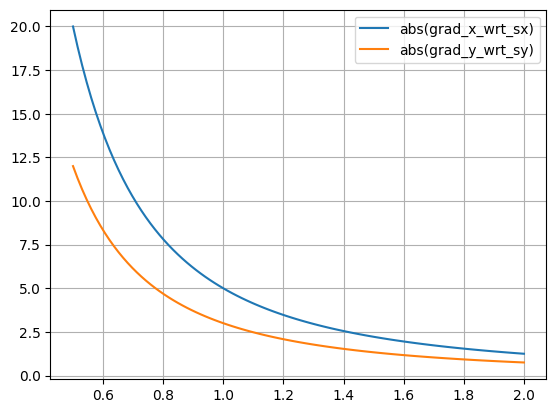

In [13]:
import matplotlib.pyplot as plt
import numpy as np

x0_val = 14
y0_val = 14
x_val = 9
y_val = 17

sx_vals = np.linspace(0.5, 2.0, 100)
sy_vals = np.linspace(0.5, 2.0, 100)

grad_x_wrt_sx = -(x_val - x0_val) / (sx_vals**2)
grad_y_wrt_sy = -(y_val - y0_val) / (sy_vals**2)

plt.figure()
plt.plot(sx_vals, np.abs(grad_x_wrt_sx), label="abs(grad_x_wrt_sx)")
plt.plot(sy_vals, np.abs(grad_y_wrt_sy), label="abs(grad_y_wrt_sy)")
plt.grid()
plt.legend()
plt.show()